In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import Perceptron
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\SuNi\Downloads\train_u6lujuX_CVtuZ9i (1).csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df = df.drop(['Loan_ID'], axis=1)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


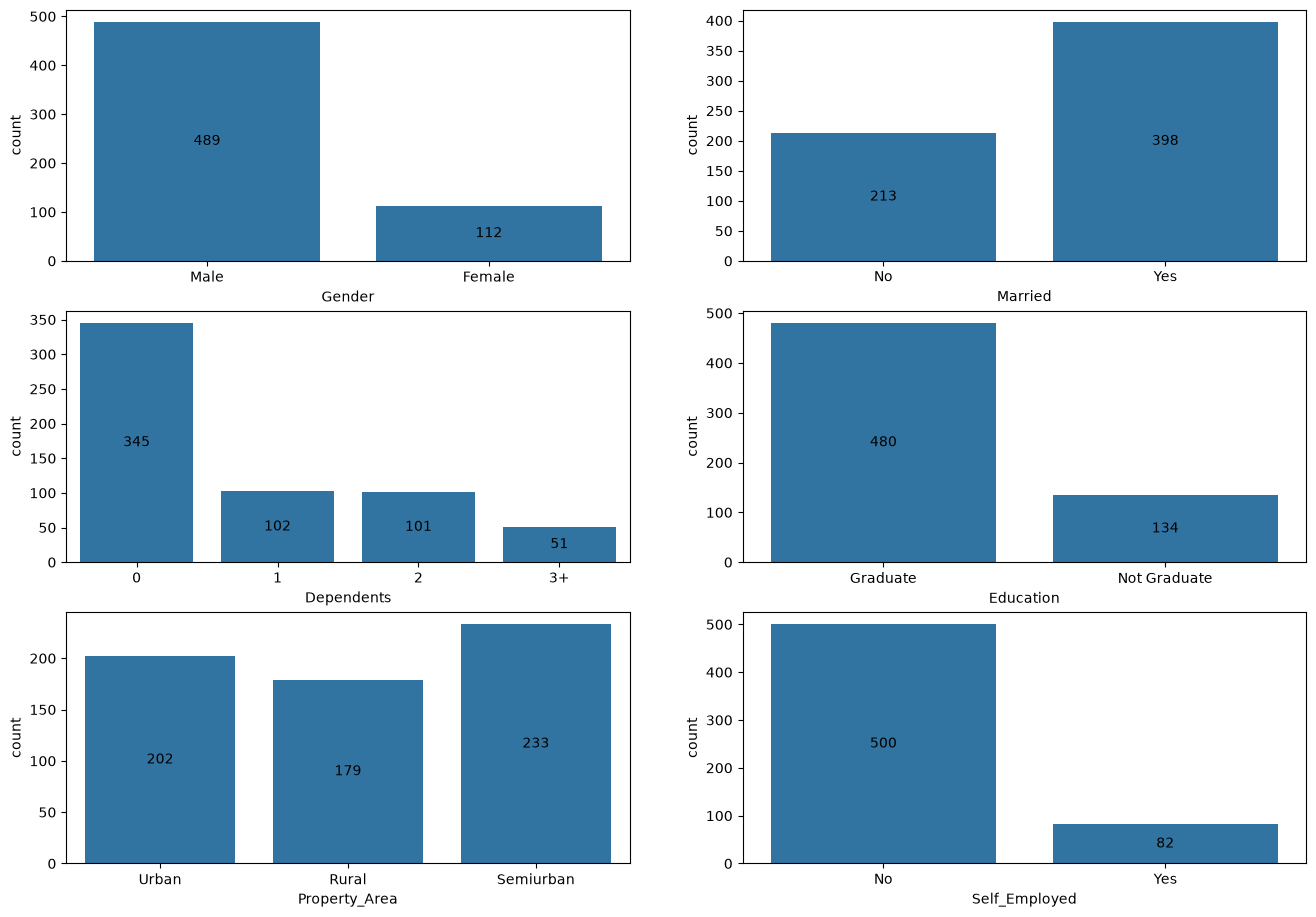

In [16]:
word_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Property_Area', 'Self_Employed' ]

fig = plt.figure(figsize=(16, 15))

for idx, col in enumerate(word_cols):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

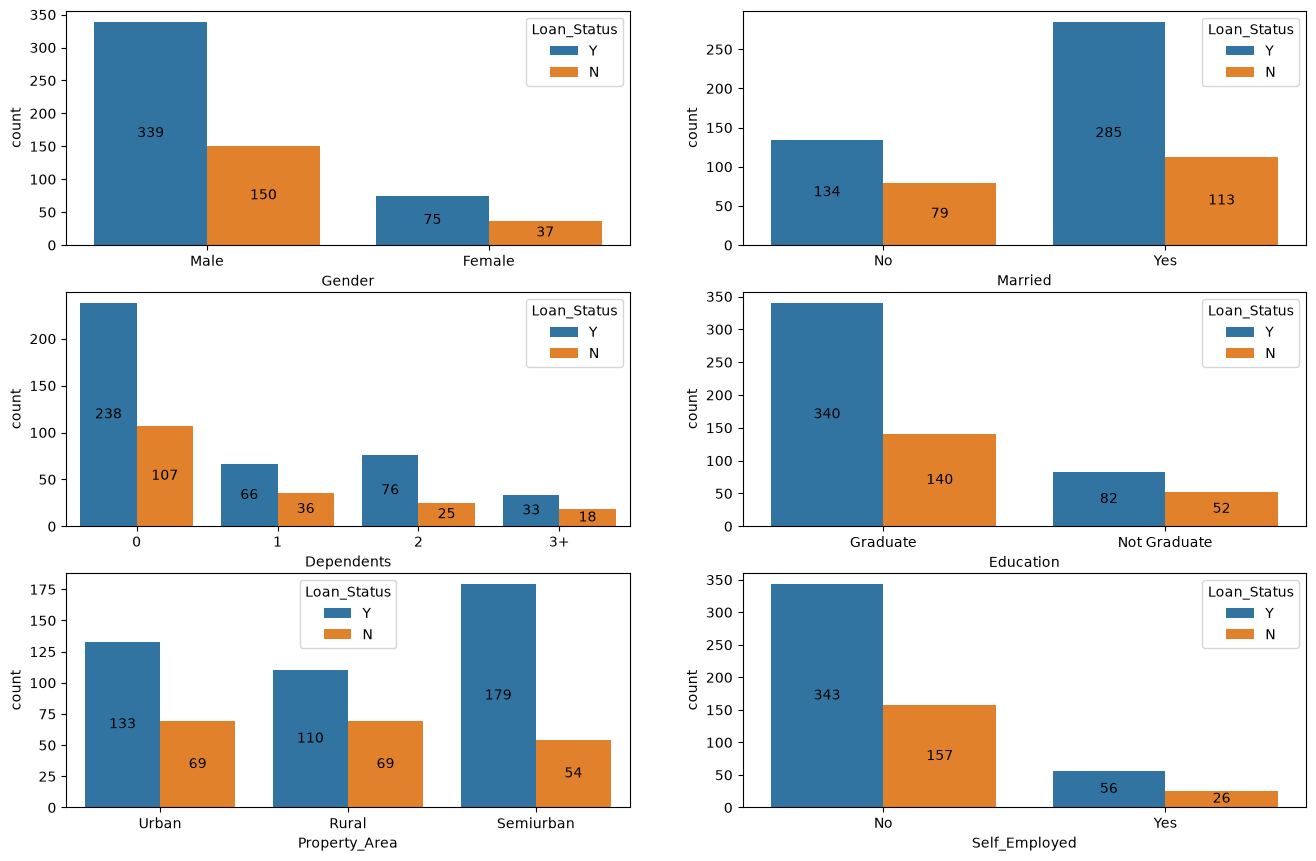

In [17]:
fig = plt.figure(figsize=(16, 14))

for idx, col in enumerate(word_cols):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], hue=df['Loan_Status'], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

In [20]:
word_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Property_Area', 'Self_Employed', 'Loan_Status']
le = LabelEncoder()
for col in word_cols:
    df[col] = le.fit_transform(df[col].astype(str))

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [22]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.838762,0.657980,0.842020,0.218241,0.237785,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,0.421752,0.484971,1.120531,0.413389,0.534737,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,2.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,2.000000,2.000000,4.000000,1.000000,2.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


In [23]:
df.isnull().any()

Gender               False
Married              False
Dependents           False
Education            False
Self_Employed        False
ApplicantIncome      False
CoapplicantIncome    False
LoanAmount           False
Loan_Amount_Term     False
Credit_History       False
Property_Area        False
Loan_Status          False
dtype: bool

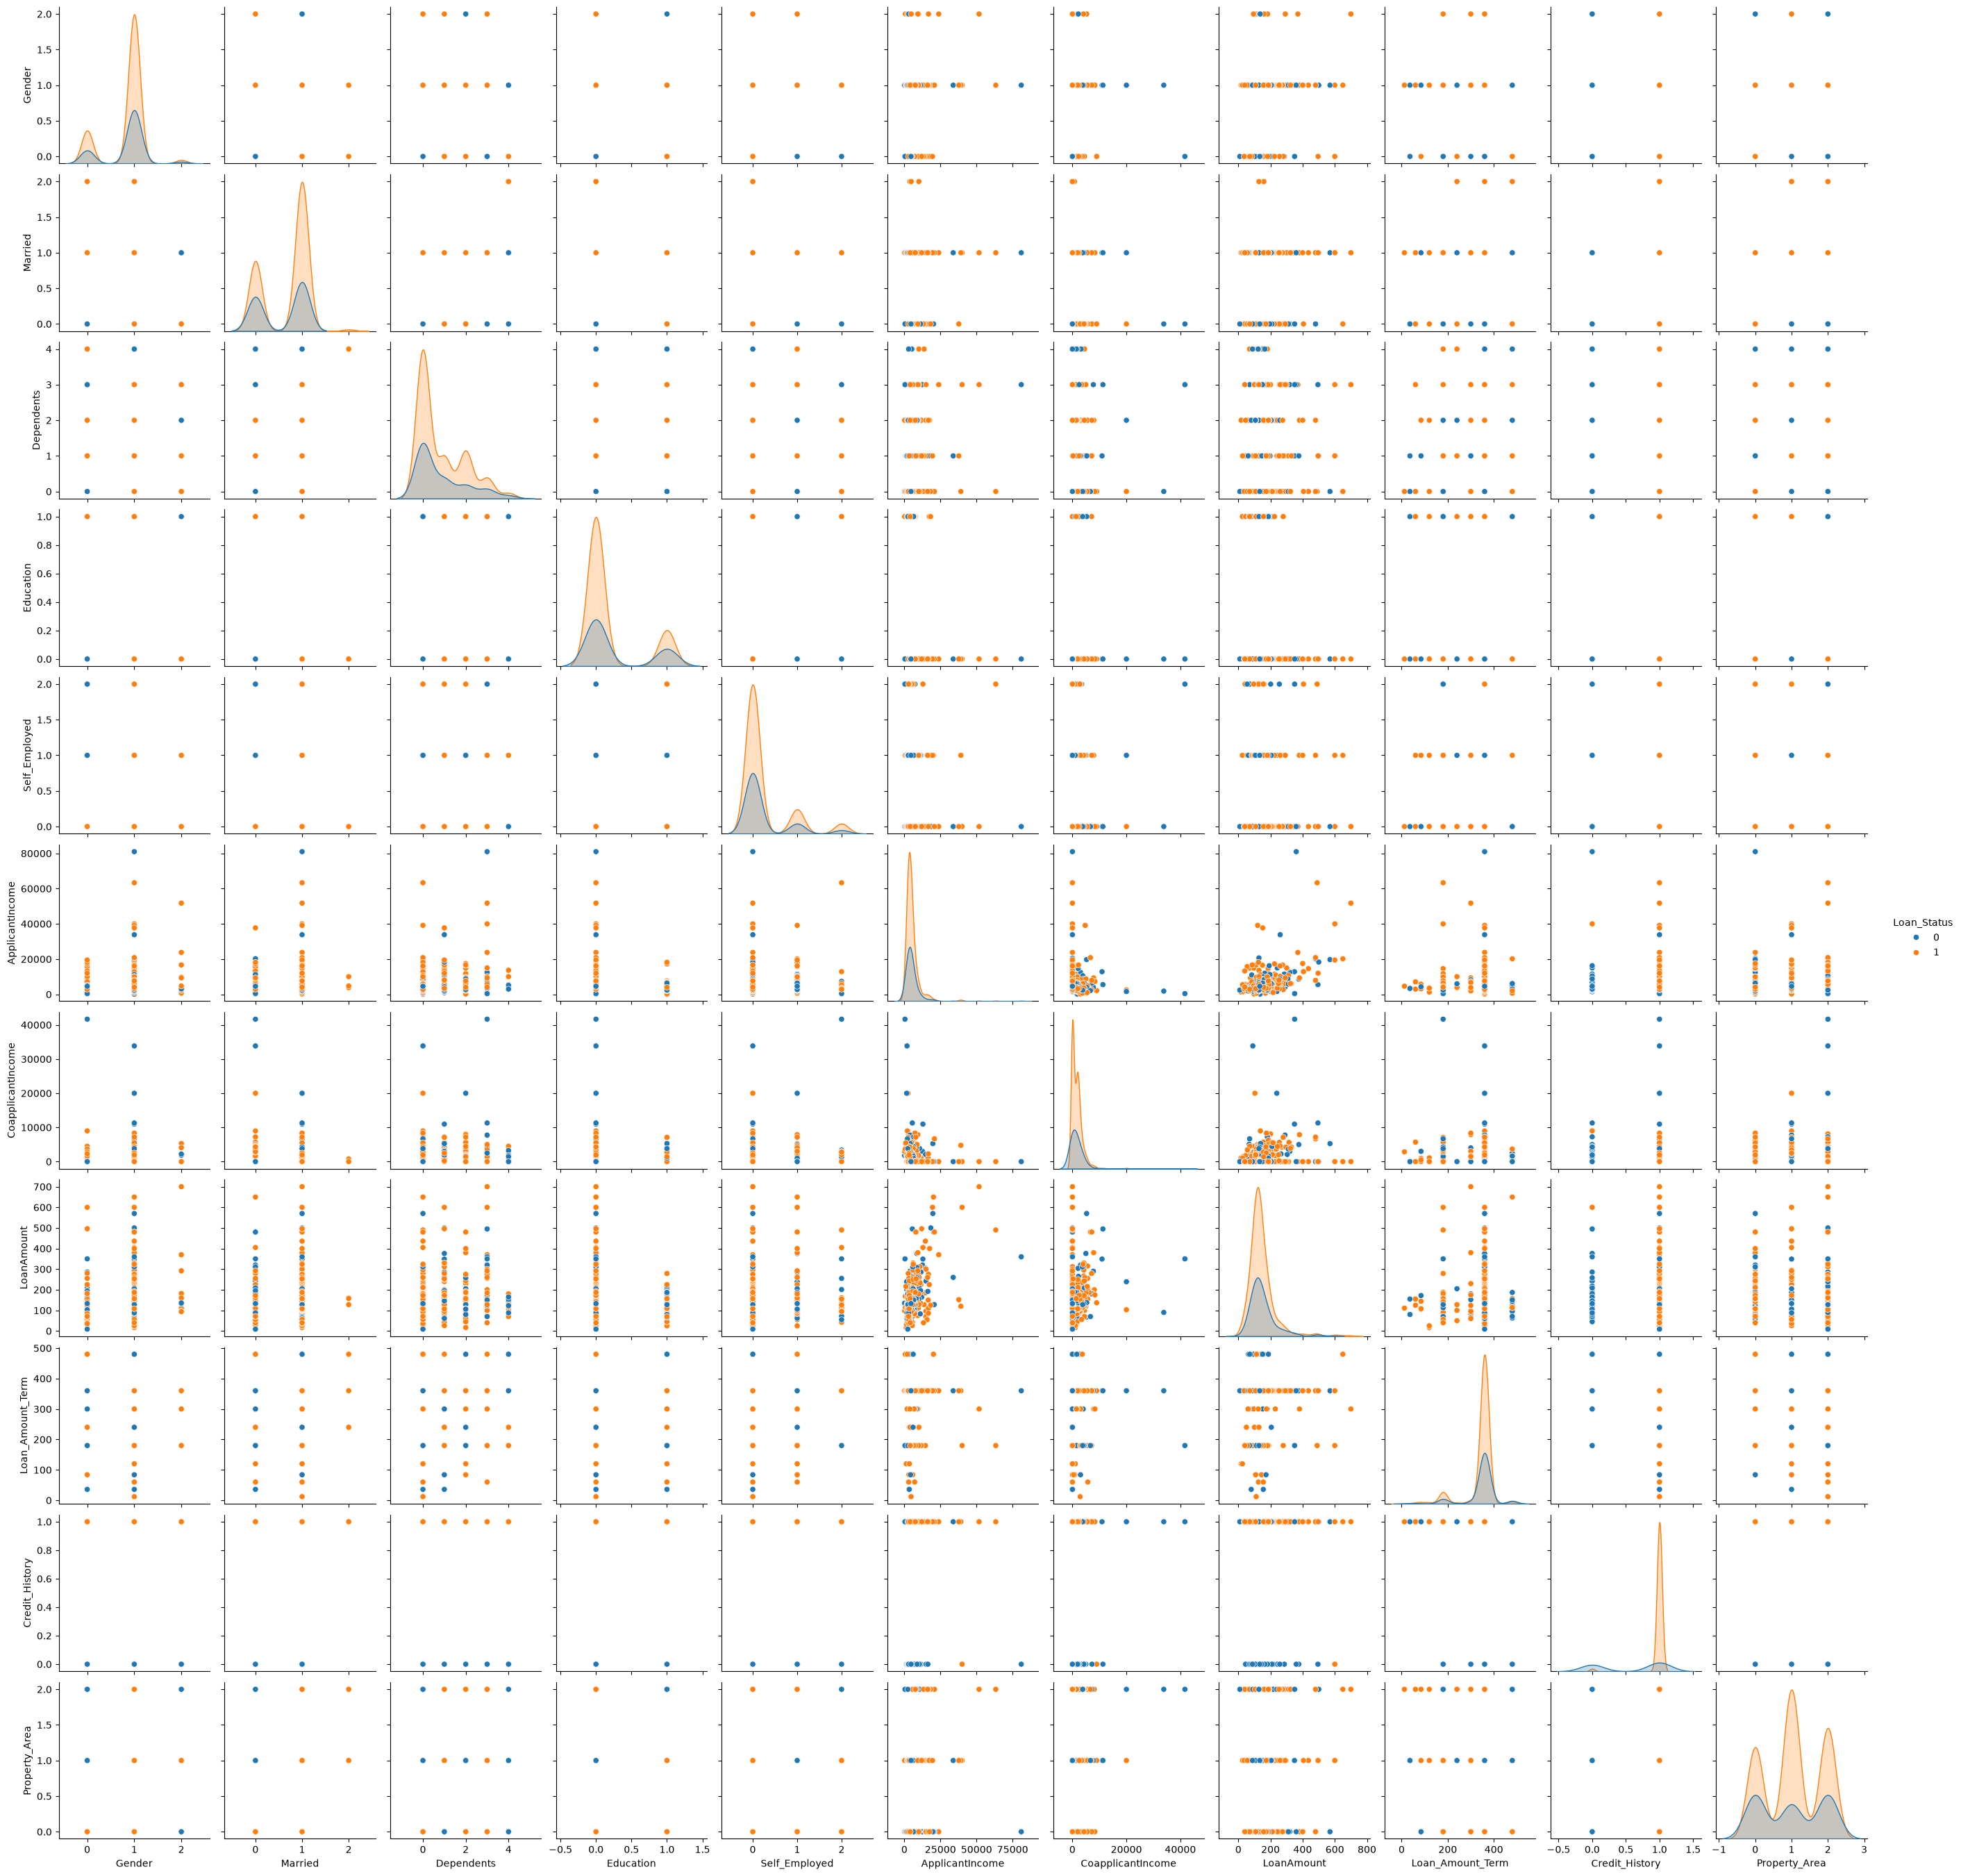

In [24]:
sns.pairplot(df, hue='Loan_Status')

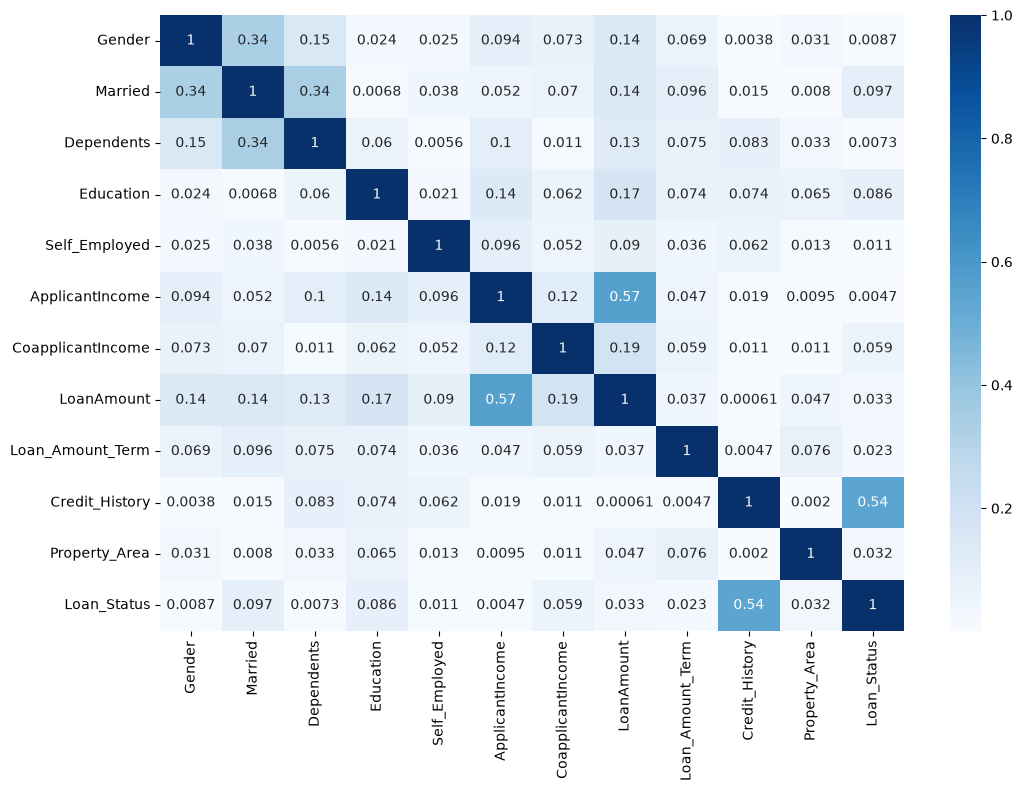

In [25]:
fig = plt.figure(figsize=(12, 8))

corr = abs(df.corr(numeric_only=True))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

In [26]:
X = df.drop(['Loan_Status'], axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

per = Perceptron(max_iter=1000, random_state=42)
per.fit(X_train_scaled, y_train)
predicts_per = per.predict(X_test_scaled)
print(f'Accuracy Score:', accuracy_score(y_test, predicts_per))
print(f'Classification Repot: \n{classification_report(y_test, predicts_per)}')

Accuracy Score: 0.6504065040650406
Classification Repot: 
              precision    recall  f1-score   support

           0       0.50      0.56      0.53        43
           1       0.75      0.70      0.72        80

    accuracy                           0.65       123
   macro avg       0.62      0.63      0.63       123
weighted avg       0.66      0.65      0.65       123



In [31]:
print('--- Training Single Layer Perceptron ---')

per = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

per.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_per = per.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split = 0.1,
    verbose=1
)

loss, accuracy = per.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

--- Training Single Layer Perceptron ---
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5986 - loss: 0.7333 - val_accuracy: 0.5400 - val_loss: 0.7555
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6122 - loss: 0.7174 - val_accuracy: 0.5400 - val_loss: 0.7374
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6259 - loss: 0.7016 - val_accuracy: 0.5400 - val_loss: 0.7183
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6349 - loss: 0.6869 - val_accuracy: 0.5600 - val_loss: 0.7005
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6485 - loss: 0.6728 - val_accuracy: 0.5600 - val_loss: 0.6825
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6599 - loss: 0.6595 - val_accuracy: 0.6000 - val_loss: 0.6666
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6689 - loss: 0.6468 - val_accuracy: 0.6000 - val_loss: 0.6510
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6712 - loss

In [39]:
print('\n--- Training Deep Artificial Neural Network (ANN) ---')

model_ann = keras.Sequential([
    layers.Input(shape =(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model_ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_ann = model_ann.fit(
    X_train_scaled, y_train, 
    epochs=50,
    batch_size=16,
    validation_split = 0.1,
    verbose=1
)

loss, accuracy = model_ann.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


--- Training Deep Artificial Neural Network (ANN) ---
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6485 - loss: 0.6700 - val_accuracy: 0.7000 - val_loss: 0.6487
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6984 - loss: 0.5964 - val_accuracy: 0.7800 - val_loss: 0.5663
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7528 - loss: 0.5367 - val_accuracy: 0.8400 - val_loss: 0.5149
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7755 - loss: 0.5255 - val_accuracy: 0.8400 - val_loss: 0.4795
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7710 - loss: 0.5108 - val_accuracy: 0.8200 - val_loss: 0.4577
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7800 - loss: 0.5030 - val_accuracy: 0.8200 - val_loss: 0.4456
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7891 - loss: 0.4859 - val_accuracy: 0.8400 - val_loss: 0.4320
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 

In [40]:
print('\n--- Training 1D Convolutional Neural Network (CNN) ---')

X_train_cnn = np.expand_dims(X_train_scaled, axis=-1)
X_test_cnn = np.expand_dims(X_test_scaled, axis=-1)

model_cnn = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs = 50,
    batch_size = 16,
    validation_split = 0.1,
    verbose = 1
)

loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


--- Training 1D Convolutional Neural Network (CNN) ---
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6531 - loss: 0.6551 - val_accuracy: 0.7800 - val_loss: 0.5668
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6871 - loss: 0.6043 - val_accuracy: 0.7800 - val_loss: 0.5235
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7188 - loss: 0.5609 - val_accuracy: 0.8200 - val_loss: 0.4925
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7846 - loss: 0.5206 - val_accuracy: 0.8000 - val_loss: 0.4685
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8050 - loss: 0.4993 - val_accuracy: 0.8200 - val_loss: 0.4499
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8186 - loss: 0.4782 - val_accuracy: 0.8200 - val_loss: 0.4528
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8141 - loss: 0.4641 - val_accuracy: 0.8200 - val_loss: 0.4346
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - ac

In [41]:
def plot_training(history, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train_acc')
    plt.plot(history.history['val_accuracy'], label='Val_acc')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


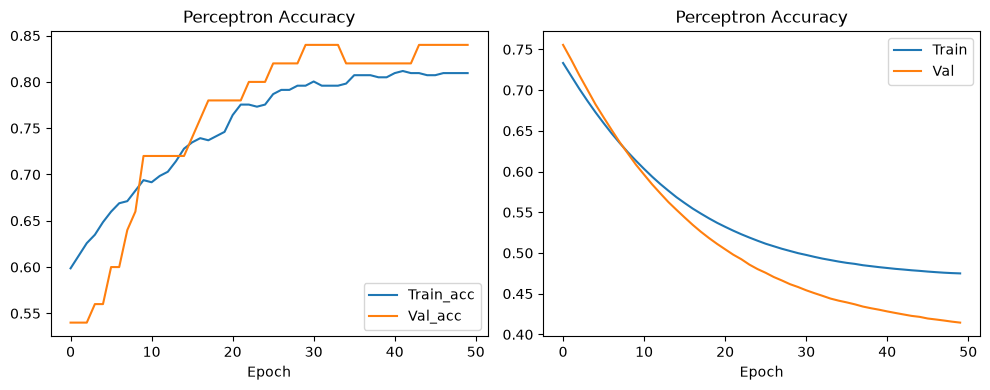

In [43]:
plot_training(history_per, "Perceptron")

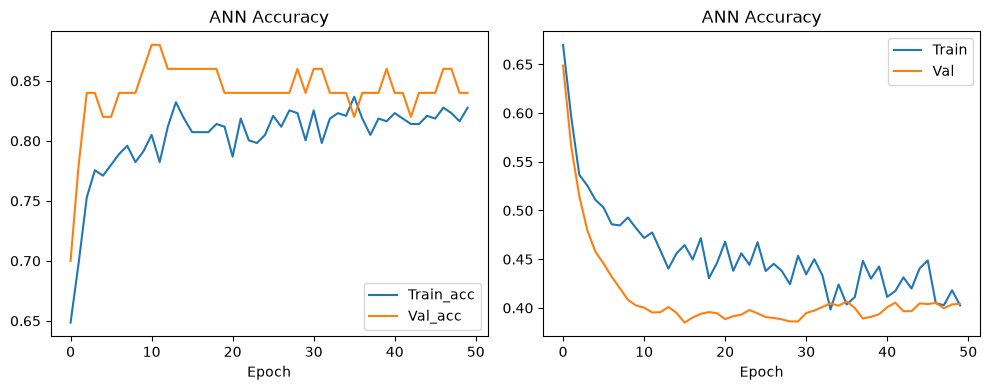

In [44]:
plot_training(history_ann, "ANN")

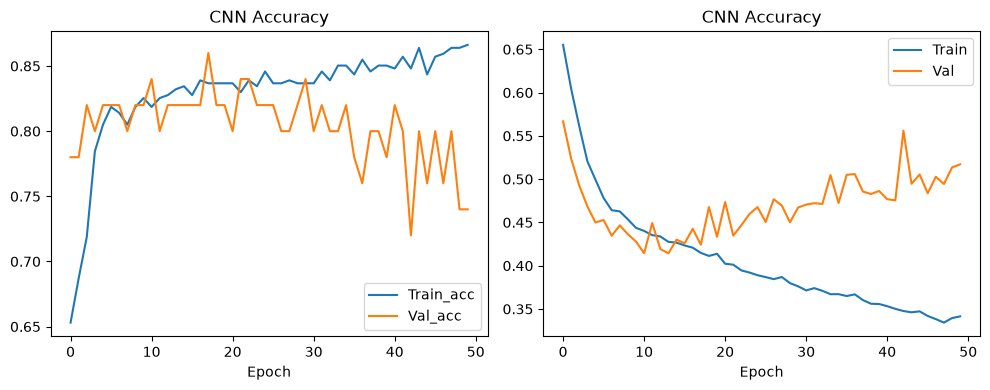

In [45]:
plot_training(history_cnn, "CNN")

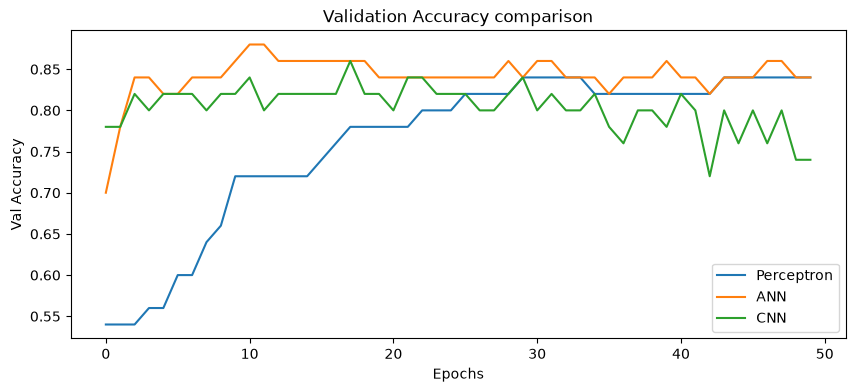

In [46]:
plt.figure(figsize=(10,4))
plt.plot(history_per.history['val_accuracy'], label='Perceptron')
plt.plot(history_ann.history['val_accuracy'], label='ANN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.title('Validation Accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()